<a href="https://colab.research.google.com/github/yahelmenahem/yahel/blob/main/podcasts.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# שלב 0 : העלאת הנתונים





---



In [3]:
from google.colab import files
uploaded = files.upload()

Saving train-2.csv to train-2.csv


# שלב 1 : הצגת סטטיסטיקות על הנתונים

In [4]:
import pandas as pd

# טעינת הקובץ
df = pd.read_csv("train-2.csv")

# הצגת 5 השורות הראשונות
print("Head (First 5)")
display(df.head())

# הצגת 5 השורות האחרונות
print(" Tail (Last 5)")
display(df.tail())

#הצגת 5 שורות רנדומליות
print("Sample (Random 5)")
display(df.sample(5))

Head (First 5)


,id,Name,Event_Number,Event_Length_minutes,Genre,Host_Popularity_percentage,Event_Day,Publication_Time,Guest_Popularity_percentage,Number_of_Sponsers,Event_Sentiment,Watch_Time_minutes
0,0,Mystery Matters,Episode 98,NaN,True Crime,74.81,Thursday,Night,NaN,0.0,Positive,31.41998
1,1,Joke Junction,Episode 26,119.80,Comedy,66.95,Saturday,Afternoon,75.95,2.0,Negative,88.01241
2,2,Study Sessions,Episode 16,73.90,Education,69.97,Tuesday,Evening,8.97,0.0,Negative,44.92531
3,3,Digital Digest,Episode 45,67.17,Technology,57.22,Monday,Morning,78.70,2.0,Positive,46.27824
4,4,Mind & Body,Episode 86,110.51,Health,80.07,Monday,Afternoon,58.68,3.0,Neutral,75.61031


 Tail (Last 5)


,id,Name,Event_Number,Event_Length_minutes,Genre,Host_Popularity_percentage,Event_Day,Publication_Time,Guest_Popularity_percentage,Number_of_Sponsers,Event_Sentiment,Watch_Time_minutes
749995,749995,Learning Lab,Episode 25,75.66,Education,69.36,Saturday,Morning,NaN,0.0,Negative,56.87058
749996,749996,Business Briefs,Episode 21,75.75,Business,35.21,Saturday,Night,NaN,2.0,Neutral,45.46242
749997,749997,Lifestyle Lounge,Episode 51,30.98,Lifestyle,78.58,Thursday,Morning,84.89,0.0,Negative,15.26000
749998,749998,Style Guide,Episode 47,108.98,Lifestyle,45.39,Thursday,Morning,93.27,0.0,Negative,100.72939
749999,749999,Sports Central,Episode 99,24.10,Sports,22.45,Saturday,Night,36.72,0.0,Neutral,11.94439


Sample (Random 5)


,id,Name,Event_Number,Event_Length_minutes,Genre,Host_Popularity_percentage,Event_Day,Publication_Time,Guest_Popularity_percentage,Number_of_Sponsers,Event_Sentiment,Watch_Time_minutes
626691,626691,Laugh Line,Episode 9,98.27,Comedy,97.27,Saturday,Night,60.25,0.0,Negative,62.05379
113711,113711,Gadget Geek,Episode 36,68.07,Technology,95.44,Friday,Night,NaN,0.0,Positive,64.66071
388081,388081,Healthy Living,Episode 71,85.89,Health,26.72,Friday,Morning,60.09,2.0,Negative,50.60405
504043,504043,Home & Living,Episode 83,55.71,Lifestyle,79.43,Thursday,Morning,87.81,1.0,Neutral,44.74544
36355,36355,Athlete's Arena,Episode 67,76.32,Sports,63.05,Monday,Night,23.76,1.0,Negative,63.58809


השתמשנו כאן בפונקציות מההרצאה `df.head()`
 אשר שולפת את השורות הראשונות מהטבלא (הברירת מחדל שלה מההגדרה היא לשלוף 5 שורות ראשונות) . אם הייתי רוצה להראות יותר הייתי מוסיפה את הכמות בתוך הסוגריים . הוספתי גם את 5 השורות האחרונות ו5 שורות רנדומליות.

In [5]:
# הגדרת המשתנים הנומריים
num_cols = df.select_dtypes(include=['number']).columns

# הצגת הסטטיסטיקה התיאורטית
# .T הופך את הטבלה כדי שיהיה נוח לקרוא את העמודות בשורות
numeric_analysis = df[num_cols].describe().T
numeric_analysis

,count,mean,std,min,25%,50%,75%,max
id,750000.0,374999.500000,216506.495284,0.0,187499.75000,374999.50000,562499.25000,749999.00
Event_Length_minutes,662907.0,64.504738,32.969603,0.0,35.73000,63.84000,94.07000,325.24
Host_Popularity_percentage,750000.0,59.859901,22.873098,1.3,39.41000,60.05000,79.53000,119.46
Guest_Popularity_percentage,603970.0,52.236449,28.451241,0.0,28.38000,53.58000,76.60000,119.91
Number_of_Sponsers,749999.0,1.348855,1.151130,0.0,0.00000,1.00000,2.00000,103.91
Watch_Time_minutes,750000.0,45.437406,27.138306,0.0,23.17835,43.37946,64.81158,119.97


הערה : לניתוח הסטטיסטי בשורה הראשונה אין משמעות אמיתית מכיוון שמדובר נטו במספר סידורי ובהמשך נתעלם ממנה

In [6]:
# הגדרת המשתנים הקטגוריאליים
cat_cols = df.select_dtypes(include=['object']).columns

# בדיקת שכיחות וייחודיות
categorical_analysis = df[cat_cols].describe().T
categorical_analysis

,count,unique,top,freq
Name,750000,48,Tech Talks,22847
Event_Number,750000,100,Episode 71,10515
Genre,750000,10,Sports,87606
Event_Day,750000,7,Sunday,115946
Publication_Time,750000,4,Night,196849
Event_Sentiment,750000,3,Neutral,251291


**הסבר** : בחלק הזה יש ניתוח לשני הסוגים השונים של הנתונים , נומרים וקטגוריאלים . עבור הנתונים הנומרים ניתן לראות את הממוצע , סטיית תקן והחציון . עבור הנתונים הקטגוריאלים ניתן לראות את הכמות של הנתונים מכל סוג , כמה קבוצות שונות יש שלהם , מי הכי נפוץ וכמה פעמים מופיע הערך הכי נפוץ .

# שלב 2 : ספירת משתנים קטגוריאלים ונומרים

In [7]:
# שלב 2: ספירת משתנים קטגוריאליים ונומריים

# 1. ספירת כמות העמודות מכל סוג
num_count = len(df.select_dtypes(include=['number']).columns)
cat_count = len(df.select_dtypes(include=['object']).columns)

# 2. הצגת התוצאה בטבלה קטנה
counts_df = pd.DataFrame({
    'סוג משתנה': ['נומרים', 'קטגוריאלים'],
    'כמות': [num_count, cat_count]
})

print(" סיכום כמות המשתנים בדאטאסט")
display(counts_df)


 סיכום כמות המשתנים בדאטאסט


,סוג משתנה,כמות
0,נומרים,6
1,קטגוריאלים,6


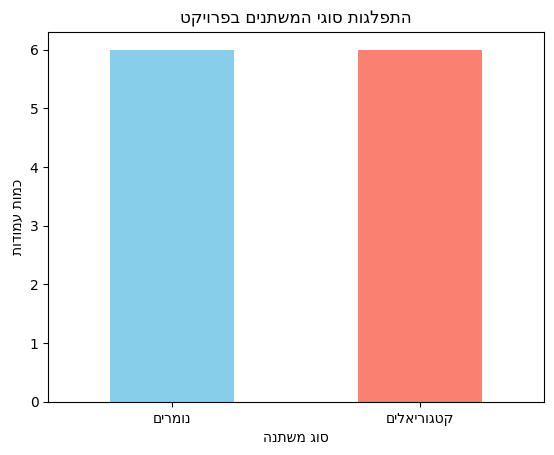

In [8]:
import matplotlib.pyplot as plt

# פונקציה קטנה שהופכת טקסט (כדי שיוצג נכון בעברית)
def reverse_he(text):
    return text[::-1]

# הכנת הנתונים עם טקסט הפוך
display_df = counts_df.copy()
display_df['סוג משתנה'] = display_df['סוג משתנה'].apply(reverse_he)

# יצירת הגרף
display_df.plot(kind='bar', x='סוג משתנה', y='כמות', legend=False, color=['skyblue', 'salmon'])

# הפיכת הכותרות
plt.title(reverse_he('התפלגות סוגי המשתנים בפרויקט'))
plt.ylabel(reverse_he('כמות עמודות'))
plt.xlabel(reverse_he('סוג משתנה'))

plt.xticks(rotation=0)
plt.show()

# שלב 3 : תיאור המשתנים הקטגוריאלים

In [9]:
# 1. הגדרת המשתנים הקטגוריאליים
cat_cols = df.select_dtypes(include=['object']).columns

# 2. יצירת הניתוח הבסיסי (count, unique, top, freq)
categorical_analysis = df[cat_cols].describe().T

# 3. הוספת עמודה לערך הכי פחות נפוץ (Least_Common)
# אנחנו עוברים על כל עמודה ומוצאים את הערך האחרון ב-value_counts
least_common_values = []
for col in cat_cols:
    least_common_values.append(df[col].value_counts().idxmin())

categorical_analysis['least_common'] = least_common_values

# 4. הצגת הטבלה המורחבת
print(" Categorical Variables Analysis (Including Least Common)")
categorical_analysis

 Categorical Variables Analysis (Including Least Common)


,count,unique,top,freq,least_common
Name,750000,48,Tech Talks,22847,News Roundup
Event_Number,750000,100,Episode 71,10515,Episode 95
Genre,750000,10,Sports,87606,Education
Event_Day,750000,7,Sunday,115946,Tuesday
Publication_Time,750000,4,Night,196849,Morning
Event_Sentiment,750000,3,Neutral,251291,Positive


ניתן לראות מהטבלא שיש 48 סוגים שונים של פודקטסטים , המחולקים ל10 ג'אנרים שונים . היום שמאזינים בו הכי הרבה לפודקאסטים הוא יום ראשון והשעה הפופולארית ביותר היא בלילה . הז'אנר השכיח ביותר הוא ספורט (מוזרים...) . כמות הפרקים נעים בין 1 ל100 והנפוץ ביותר הוא 71 . הוספתי גם את הז'אנר הכי פחות נפוץ שהוא השכלה .

*   נ.ב : הז'אנר הכי נפוץ הכוונה שהוא הכי נפוץ בדאטה סט שלנו , כלומר פורסמו ממנו הכי הרבה פרקים אבל זה לא דווקא אומר ששומעים אותו גם הכי הרבה   



# שלב 4 : תיאור המשתנים הנומרים

In [10]:
# We exclude 'id' as it is a serial identifier and not a statistical variable
numerical_cols = [col for col in df.select_dtypes(include=['number']).columns if col != 'id']
numerical_desc = df[numerical_cols].describe().T

print("--- Numerical Variables Description ---")
display(numerical_desc)

--- Numerical Variables Description ---


,count,mean,std,min,25%,50%,75%,max
Event_Length_minutes,662907.0,64.504738,32.969603,0.0,35.73000,63.84000,94.07000,325.24
Host_Popularity_percentage,750000.0,59.859901,22.873098,1.3,39.41000,60.05000,79.53000,119.46
Guest_Popularity_percentage,603970.0,52.236449,28.451241,0.0,28.38000,53.58000,76.60000,119.91
Number_of_Sponsers,749999.0,1.348855,1.151130,0.0,0.00000,1.00000,2.00000,103.91
Watch_Time_minutes,750000.0,45.437406,27.138306,0.0,23.17835,43.37946,64.81158,119.97


*   ניתן לראות מהטבלא הזו כמה דברים מעניינים : ראשית , רוב המאזינים לא באמת מסיימים פרק , מכיוון זמן הפרק הממוצע הוא 64.5 דקות אבל זמן הצפיה הוא 45 דקות . לרוב יהיה ספונסר 1 לפרק . המארחים נהנים מפופולאריות גבוה יותר מהאורחים . המאחרים בעלי 60 אחוז פופולאריות ואילו האורחים 52.
*   היו מקרים חריגים שהיו 103 ספונסרים לפרק (איך הם הגיעו לזה לעזאזל?)



# שלב 5 : זיהוי המשתנים החסרים

In [11]:
# Step 5: Identifying Missing Values

# 1. Calculating the number of missing values per column
missing_values = df.isnull().sum()

# 2. Calculating the percentage of missing values (for deeper analysis)
missing_percentage = (df.isnull().sum() / len(df)) * 100

# 3. Creating a summary table for missing values
missing_df = pd.DataFrame({
    'Missing Values': missing_values,
    'Percentage (%)': missing_percentage
})

# Displaying only columns that actually have missing values
print("--- Missing Values Analysis ---")
display(missing_df[missing_df['Missing Values'] > 0])

--- Missing Values Analysis ---


,Missing Values,Percentage (%)
Event_Length_minutes,87093,11.612400
Guest_Popularity_percentage,146030,19.470667
Number_of_Sponsers,1,0.000133




*   חסרים 11.6% מהדאטה של זמן הפרק הממוצע וזה בעייתי כי זה משפיע על הניתוח של זמן האזנה ביחס לאורך הפרק
*   חסרים 19.5% מהדאטה על פופולאריות האורחים (יש מצב שזה כי לא היה אורח פשוט)
*   חסר רק ערך אחד של כמות הספונסרים וזה זניח ביחס כמות דאטה שלנו








# שלב 6 : טיפול בערכים חסרים

In [12]:
# Step 6: Handling Missing Values

# 1. Handling 'Event_Length_minutes' - Filling with Median
event_length_median = df['Event_Length_minutes'].median()
df['Event_Length_minutes'] = df['Event_Length_minutes'].fillna(event_length_median)

# 2. Handling 'Guest_Popularity_percentage' - Filling with 0
# Logic: If data is missing, we assume there was no guest.
df['Guest_Popularity_percentage'] = df['Guest_Popularity_percentage'].fillna(0)

# 3. Handling 'Number_of_Sponsers' - Filling with 0
df['Number_of_Sponsers'] = df['Number_of_Sponsers'].fillna(0)

# Verification: Check if there are any missing values left
print("--- Missing Values after Cleaning ---")
print(df.isnull().sum())

--- Missing Values after Cleaning ---
id                             0
Name                           0
Event_Number                   0
Event_Length_minutes           0
Genre                          0
Host_Popularity_percentage     0
Event_Day                      0
Publication_Time               0
Guest_Popularity_percentage    0
Number_of_Sponsers             0
Event_Sentiment                0
Watch_Time_minutes             0
dtype: int64


הסבר

*   בזמן פרק ממוצע משלימים את הערכים להיות החציון
*   אם אין נתון על פופולאריות האורח ממלאים 0 מתוך הנחה שהפרק היה  סולו

אימות מתבצע על ידי

```
# df.isnull().sum())
```

 ומאשרים שהעמודות מלאות ב 100% .

---

  אחרי שיש לנו את כל זה אפשר להמשיך לניתוחים ויזואלים וסטטיסטים מדוייקים.



# שלב 7 : איתור וטיפול בערכי קיצון במידה ויש

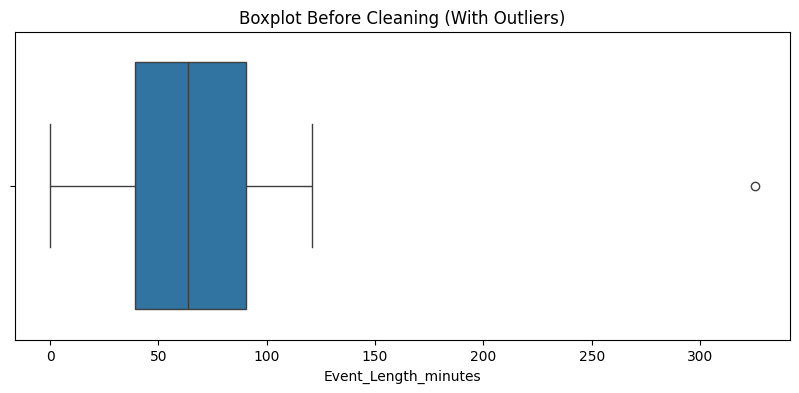

Lower Bound: -36.915000000000006, Upper Bound: 166.645
Original rows: 750000
Rows after cleaning: 749999
Outliers removed: 1


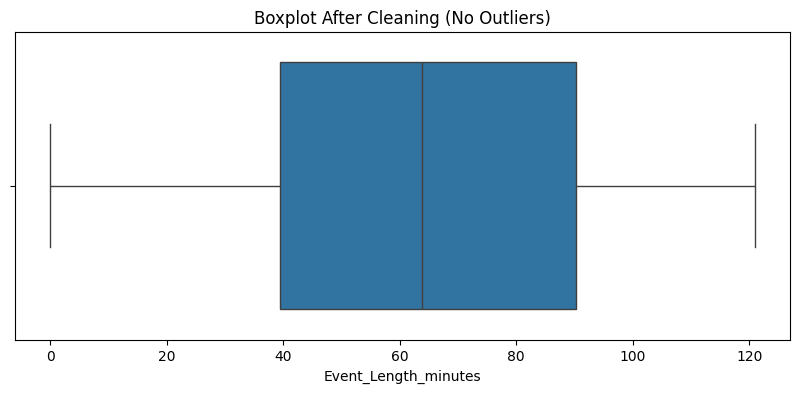

In [13]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# --- חלק א: ויזואליזציה "לפני" (כדי לראות את הבעיה) ---
plt.figure(figsize=(10, 4))
sns.boxplot(x=df['Event_Length_minutes'])
plt.title('Boxplot Before Cleaning (With Outliers)')
plt.show()

# --- חלק ב: החישוב הסטטיסטי (שיטת IQR) ---

# 1. חישוב הרבעונים (Q1 ו-Q3)
Q1 = df['Event_Length_minutes'].quantile(0.25) # הרבעון הראשון (25%)
Q3 = df['Event_Length_minutes'].quantile(0.75) # הרבעון השלישי (75%)

# 2. חישוב הטווח הבין-רבעוני (IQR)
IQR = Q3 - Q1

# 3. הגדרת הגבולות (העליון והתחתון)
# כל מה שחורג מהגבולות האלו נחשב "חריג"
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"Lower Bound: {lower_bound}, Upper Bound: {upper_bound}")

# --- חלק ג: הסינון בפועל ---

# יצירת תנאי שמשאיר רק את מה ש"בתוך הגבולות"
# אנחנו מבקשים: תן לי את השורות שבהן הערך גדול מהגבול התחתון וגם קטן מהגבול העליון
df_clean = df[(df['Event_Length_minutes'] >= lower_bound) & (df['Event_Length_minutes'] <= upper_bound)]

print(f"Original rows: {len(df)}")
print(f"Rows after cleaning: {len(df_clean)}")
print(f"Outliers removed: {len(df) - len(df_clean)}")

# עדכון הדאטא-פריים הראשי (אם את רוצה לשמור את השינוי)
df = df_clean

# --- חלק ד: ויזואליזציה "אחרי" (כדי לראות את השיפור) ---
plt.figure(figsize=(10, 4))
sns.boxplot(x=df['Event_Length_minutes'])
plt.title('Boxplot After Cleaning (No Outliers)')
plt.show()

משתמשים בפקודה

```
# .quantile()
```   
*   מסדרים את הפודקאסטים מהקצר לארוך ומגדירים משתני עזר Q1 , Q3 להיות הנקודות שבהן חותכים את הרבע הראשון ואת השלושת רבעי האחרון . זה נותן את המרכז של הדאטה

*    מגדירים את האורך של התיבה על ידי ההפרש של שני הנקודות הללו ומסמנים אותו IQR


*  מכפילים אותו ב1.5 מתוך הנחה שמה שנמצא במרחק של יותר מפי 1.5 מהאורך של התיבה הוא חריג
*   עוברים על כל השורות וזורקים את מה שלא בגבול
* ביצענו ויזואליזציה כדאי להראות את התיבה ואת הנקודות שלא נמצאות בתחום ולאחר מכן וידאנו בעזרתה שבאמת הם הוסרו   









# שלב 8 : נרמול ערכים נומרים

In [14]:
# --- שלב 8: נרמול הנתונים (Normalization) ---

# 1. בחירת העמודות לנרמול
# אנחנו מנרמלים את המשתנים המסבירים (הפיצ'רים), אך בדרך כלל לא נוגעים במשתנה המטרה (Watch_Time) בשלב הזה
# וכמובן לא נוגעים ב-ID
cols_to_normalize = [
    'Event_Length_minutes',
    'Host_Popularity_percentage',
    'Guest_Popularity_percentage',
    'Number_of_Sponsers'
]

# 2. יצירת עותק של הדאטא (כדי לא לדרוס את המקור אם נרצה לחזור אחורה)
df_normalized = df.copy()

# 3. ביצוע הנרמול בשיטת Min-Max
for col in cols_to_normalize:
    min_val = df[col].min()
    max_val = df[col].max()

    # הנוסחה: (הערך פחות המינימום) חלקי (המקסימום פחות המינימום)
    df_normalized[col] = (df[col] - min_val) / (max_val - min_val)

# 4. בדיקה שהנרמול עבד
# אנחנו מצפים לראות שהמינימום הוא 0 והמקסימום הוא 1 בכל העמודות
print("--- Statistics After Normalization ---")
display(df_normalized[cols_to_normalize].describe().T[['min', 'max', 'mean']])

# עדכון הדאטא-פריים הראשי
df = df_normalized

--- Statistics After Normalization ---


,min,max,mean
Event_Length_minutes,0.0,1.0,0.532764
Host_Popularity_percentage,0.0,1.0,0.495598
Guest_Popularity_percentage,0.0,1.0,0.350811
Number_of_Sponsers,0.0,1.0,0.012981


אלגוריתמים של למידת מכונה רגישים מאוד לסדרי גודל לכן אנחנו רוצים להקפיד שכל משתנה יקבל משקל באותו סדר גודל . מין הסתם שלא ננרמל את המשתנה id מכיוון שהוא חסר משמעות באלגוריתמים למינהם.

---
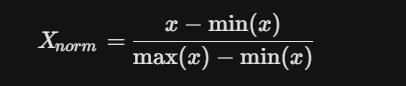

---

*  ממפים את הערכים על ידי הנוסחה הזו לטווח שבין אפס ל1
* ביצענו נרמול רק על פופולאריות , מספר הספונסרים ואורך ממוצע . ולא על זמן הצפייה כי אותו דווקא אנחנו רוצים לקבל ביחידות המקוריות


# שלב 9 : קורלציות (במילים אחרות - מה משפיע על זמן הצפיה בפודקאסט?)

In [16]:
# חלק 9.1: יצירת טבלת הקורלציה (Correlation Matrix)

# בחירת העמודות הרלוונטיות בלבד (משתנה המטרה + המשתנים המסבירים שנרמלנו)
cols_for_corr = ['Watch_Time_minutes',
                 'Event_Length_minutes',
                 'Host_Popularity_percentage',
                 'Guest_Popularity_percentage',
                 'Number_of_Sponsers']

# חישוב הקורלציה
corr_matrix = df[cols_for_corr].corr()

# הצגה מעוצבת של הטבלה (צבעים בתוך הטבלה)
print("--- Correlation Table (Darker Color = Stronger Connection) ---")
display(corr_matrix.style.background_gradient(cmap='coolwarm', axis=None).format("{:.2f}"))

--- Correlation Table (Darker Color = Stronger Connection) ---


,Watch_Time_minutes,Event_Length_minutes,Host_Popularity_percentage,Guest_Popularity_percentage,Number_of_Sponsers
Watch_Time_minutes,1.00,0.87,0.05,-0.01,-0.12
Event_Length_minutes,0.87,1.00,0.02,-0.00,-0.05
Host_Popularity_percentage,0.05,0.02,1.00,0.01,-0.02
Guest_Popularity_percentage,-0.01,-0.00,0.01,1.00,-0.03
Number_of_Sponsers,-0.12,-0.05,-0.02,-0.03,1.00


מעניינת אותנו השורה של זמן הצפיה , ככל שהערך בשורה הזו יותר קרוב ל1 ככה ההשפעה של הפיצ'אר הזה יותר גדולה ולהפך . אפשר לשים לב שמה שהכי משפיע על זמן הצפיה בפרק הוא אורך הפרק ושאר הדברים לא כל כך משפיעים.

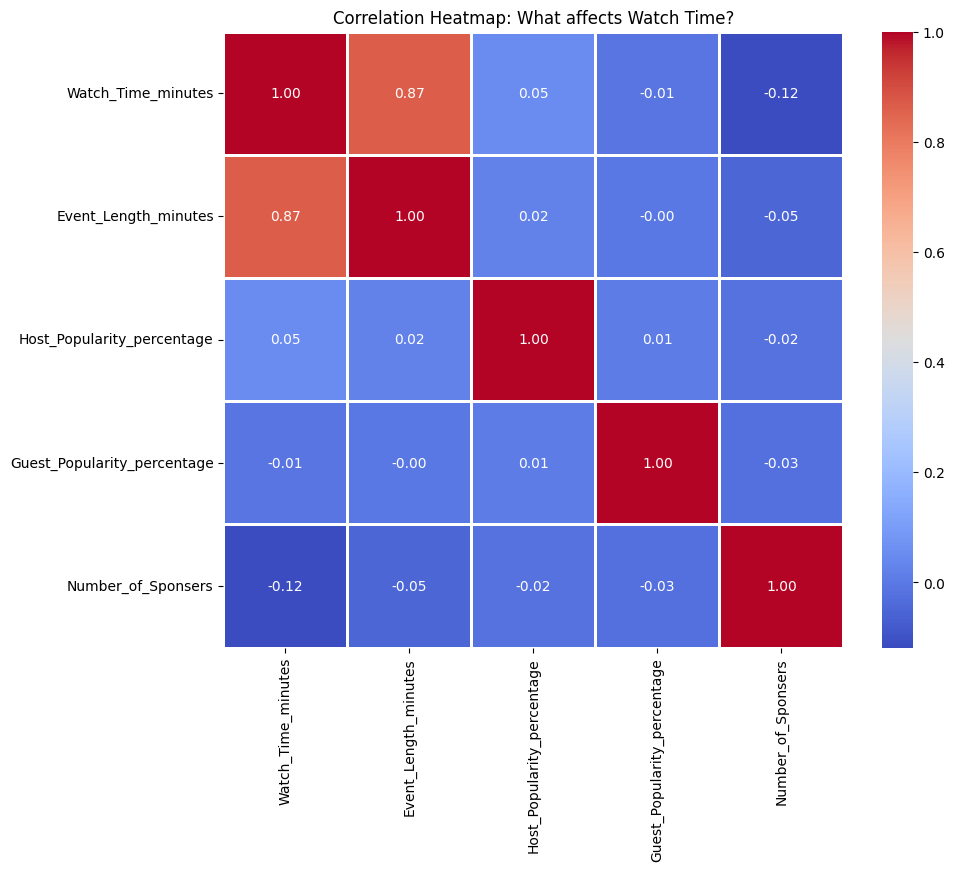

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

# חלק 9.2: הצגת מפת חום (Heatmap)

plt.figure(figsize=(10, 8)) # הגדרת גודל ציור נוח לקריאה

# יצירת המפה
sns.heatmap(corr_matrix,
            annot=True,    # כתיבת המספרים בתוך הריבועים
            cmap='coolwarm', # צבעים: כחול=חיובי, אדום=שלילי
            fmt=".2f",     # דיוק של 2 ספרות אחרי הנקודה
            linewidths=1,  # רווח לבן בין הריבועים לקריאות
            cbar=True)     # מקרא צבעים בצד

plt.title('Correlation Heatmap: What affects Watch Time?')
plt.show()

זה אותה ההבחנה רק בצורה של מפת חום ויזואלית

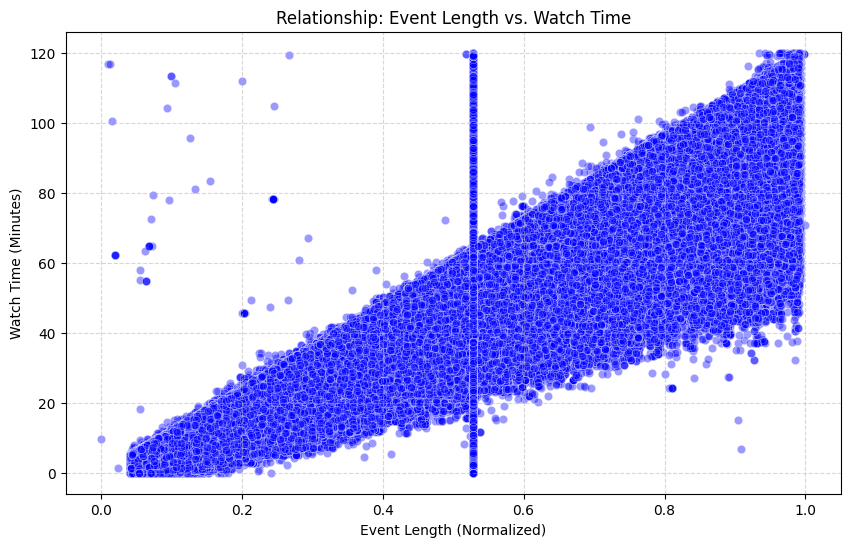

In [18]:
# חלק 9.3: גרף פיזור למשתנה החזק ביותר

# כאן אנחנו מניחים שאורך הפרק הוא המשפיע ביותר (לפי הניתוח הקודם)
plt.figure(figsize=(10, 6))

sns.scatterplot(x='Event_Length_minutes',
                y='Watch_Time_minutes',
                data=df,
                alpha=0.4,       # שקיפות כדי לראות צפיפות של נקודות
                color='blue')

plt.title('Relationship: Event Length vs. Watch Time')
plt.xlabel('Event Length (Normalized)')
plt.ylabel('Watch Time (Minutes)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

ניתן לראות כאן מגמה ברורה שהיא ככל שאורך הפרק גדול יותר ככה זמן הצפיה גדול יותר באופן כמעט לנארי

**הערה חשובה:**

*  יש באמצע קו מוזר , והוא נובע מהעובדה שבשלב קודם מלאנו את הערכים החסרים בחציון . ולכן זה לא באמת מביע את הקשר האמיתי בין זמן הצפיה לזמן הפרק .
*   כלומר הערך בציר ה X קבוע אבל בציר ה Y משתנה כי שם לא נגענו ואלו הנתונים האמיתיים



# שלב 10 : ויזואליזצית ההתפלגויות

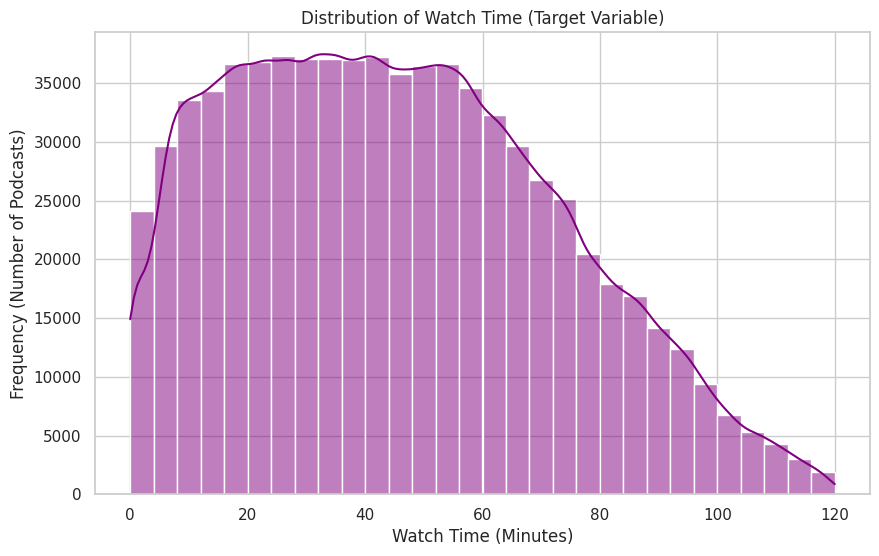

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

# יצירת היסטוגרמה עם קו צפיפות (KDE)
sns.histplot(df['Watch_Time_minutes'], kde=True, color='purple', bins=30)

plt.title('Distribution of Watch Time (Target Variable)')
plt.xlabel('Watch Time (Minutes)')
plt.ylabel('Frequency (Number of Podcasts)')
plt.show()

כאן בודקים איך מתפלג זמן הצפיה . העמודות זה ההיסטוגרמיה והקו שמחבר זה הקרנל של משך זמן הצפיה (הצורה) . ציר ה X מציצג את זמן הצפיה וציר ה Y את כמות הפודקאסטים . הנתונים נוטים שמאלה וזה לא נראה כל כך כמו פעמון סימטרי , כלומר רוב הפודקאסטים בעלי זמן צפיה נמוך יחסית . אפשר להסיק מזה על התוכן שלהם שהוא לא מספיק איכותי ולא מחזיק את המאזינים לאורך זמן .

/tmp/ipython-input-1034044338.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='Genre', data=df, order=df['Genre'].value_counts().index, palette='viridis')


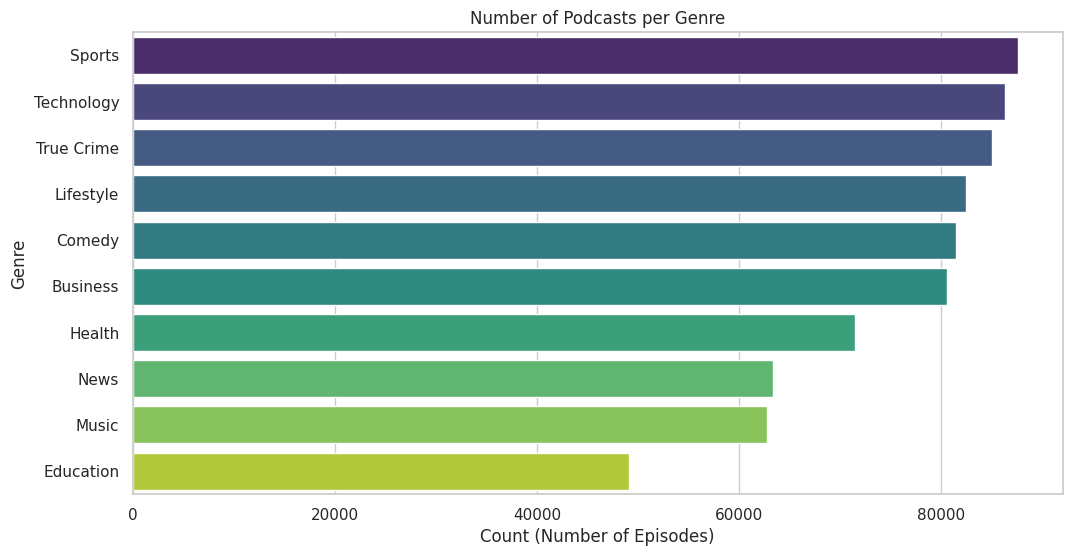

In [23]:
plt.figure(figsize=(12, 6))

# יצירת גרף עמודות הסופר כמה שורות יש מכל סוג
# הפקודה order דואגת שהגרף יהיה מסודר מהגדול לקטן
sns.countplot(y='Genre', data=df, order=df['Genre'].value_counts().index, palette='viridis')

plt.title('Number of Podcasts per Genre')
plt.xlabel('Count (Number of Episodes)')
plt.ylabel('Genre')
plt.show()

כאן אנחנו בודקים איזה ז'אנרים שולטים בדאטה סט . ניתן לראות שספורט הכי נפוץ וההשכלה הכי פחות .

/tmp/ipython-input-608522095.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Watch_Time_minutes', y='Genre', data=df, palette='magma', errorbar=None)


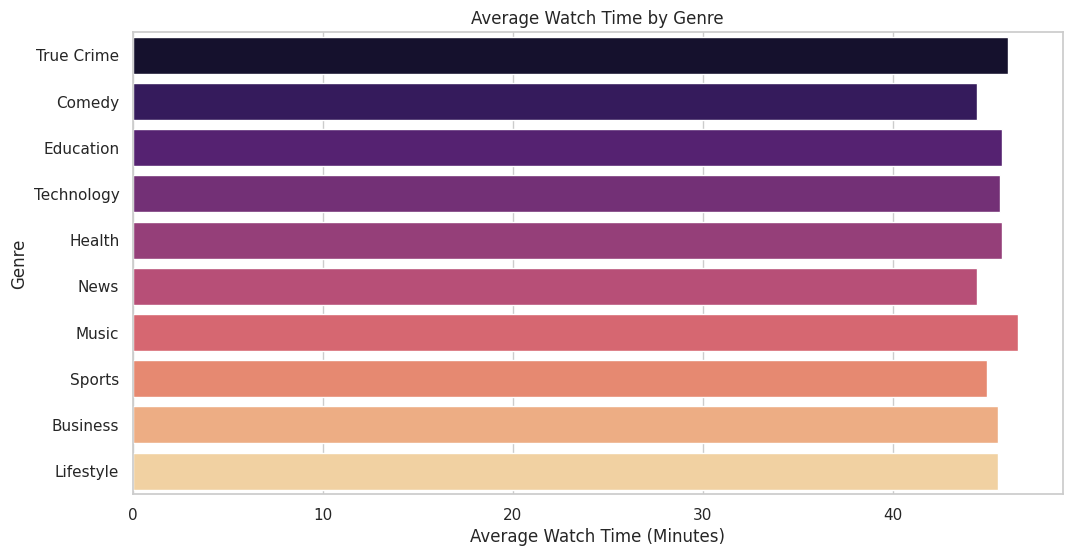

In [24]:
plt.figure(figsize=(12, 6))

# גרף המציג את ממוצע זמן הצפייה לכל ז'אנר
sns.barplot(x='Watch_Time_minutes', y='Genre', data=df, palette='magma', errorbar=None)

plt.title('Average Watch Time by Genre')
plt.xlabel('Average Watch Time (Minutes)')
plt.ylabel('Genre')
plt.show()

כאן ניתן לראות את הקשר בין הז'אנר זמן הצפיה . ודווקא אפשר לראות פה שזה שספורט הוא מפורסם הכי הרבה לווא דווקא שומעים אותו הכי הרבה . יש ז'אנרים שמדביקים את המאזין לפודקאסט יותר , כמו פשע אמיתי ומוזיקה.

/tmp/ipython-input-1050440592.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Genre', y='Event_Length_minutes', data=df, palette='coolwarm')


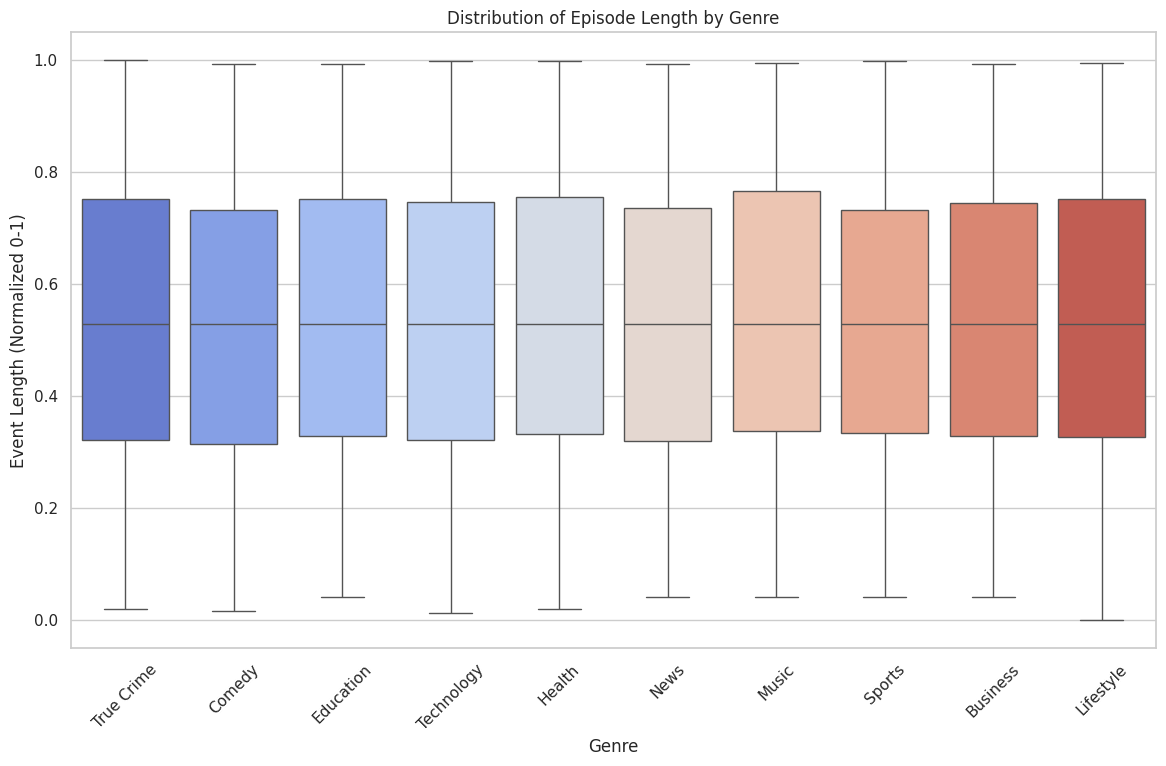

In [25]:
plt.figure(figsize=(14, 8))

# יצירת תרשים קופסה (Boxplot)
# ציר ה-X: הז'אנרים השונים
# ציר ה-Y: אורך הפרק (שימי לב: הנתונים מנורמלים בין 0 ל-1)
sns.boxplot(x='Genre', y='Event_Length_minutes', data=df, palette='coolwarm')

plt.title('Distribution of Episode Length by Genre')
plt.xlabel('Genre')
plt.ylabel('Event Length (Normalized 0-1)')
plt.xticks(rotation=45) # סיבוב השמות כדי שלא יעלו אחד על השני
plt.show()

כאן אפשר לראות את התפלגות אורך הפרק לפי הז'אנר . כל הפרקים פחות או יותר שומרים על אורך זהה. מוזיקה קצת יותר ארוך מהשאר אבל כמעט אין קשר בין הז'אנר לאורך הפרק . אולם , כן יש שונות בתוך הז'אנר , כלומר לא כל הפרקים באותו האורך תמיד.

# שלב 11 : הקשר בין המשתנים השונים לזמן הצפיה

/tmp/ipython-input-1236244734.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(ax=axes[2], x='Number_of_Sponsers', y='Watch_Time_minutes', data=df, palette='Set2')


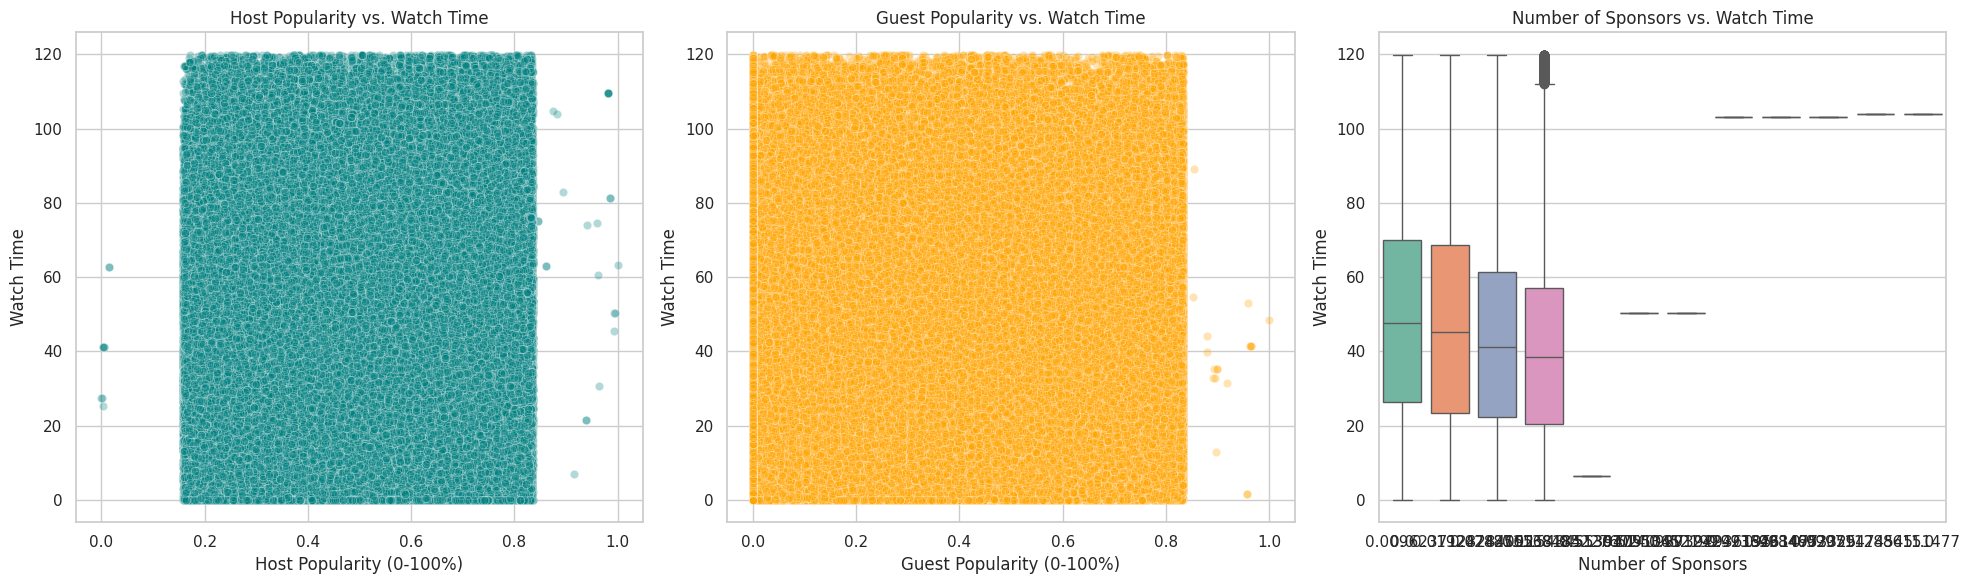

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

# הגדרת מסגרת גדולה ל-3 גרפים (שורה אחת, 3 עמודות)
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# --- גרף 1: פופולריות המארח מול זמן צפייה ---
# סוג גרף: פיזור (Scatter) - כי שני המשתנים הם רציפים
sns.scatterplot(ax=axes[0], x='Host_Popularity_percentage', y='Watch_Time_minutes', data=df, alpha=0.3, color='teal')
axes[0].set_title('Host Popularity vs. Watch Time')
axes[0].set_xlabel('Host Popularity (0-100%)')
axes[0].set_ylabel('Watch Time')

# --- גרף 2: פופולריות האורח מול זמן צפייה ---
# סוג גרף: פיזור (Scatter)
sns.scatterplot(ax=axes[1], x='Guest_Popularity_percentage', y='Watch_Time_minutes', data=df, alpha=0.3, color='orange')
axes[1].set_title('Guest Popularity vs. Watch Time')
axes[1].set_xlabel('Guest Popularity (0-100%)')
axes[1].set_ylabel('Watch Time')

# --- גרף 3: מספר הספונסרים מול זמן צפייה ---
# סוג גרף: קופסה (Boxplot) - כי מספר הספונסרים הוא מספר בודד (0, 1, 2...) ולא רציף
sns.boxplot(ax=axes[2], x='Number_of_Sponsers', y='Watch_Time_minutes', data=df, palette='Set2')
axes[2].set_title('Number of Sponsors vs. Watch Time')
axes[2].set_xlabel('Number of Sponsors')
axes[2].set_ylabel('Watch Time')

plt.tight_layout() # סידור אוטומטי של הרווחים
plt.show()

משני הגרפים הראשונים אפשר לראות שאין שום קשר בין הפופולריות של האורך או המארח לבין זמן הצפיה בפרק .

---
בגרף השלישי עשיתי קופסאות בגלל שמספר הספונסרים בדיד . אפשר לראות שדווקא ככל שמספר הספונסרים גדל ככה זמן הצפיה גדל . אפשר להסיק מזה מסקנה מעניינת על איך שמעורבות של כסף והתמסחרות משפיעה על איכות התוכן . אפשר להסיק מזה על אופי של בני אדם , שהם אוהבים אותנטיות ודווקא יעדיפו להמשיך להקשיב למי שלא ממסחר את התוכן שלו . משמעות אחרת היא שספונסרים מציקים לצופים והם עוזבים באמצע .
